# Lab 8: Custom CNN Model for Corn Leaf Image Classification

**Student Name:** Malik Awais Bashir  
**Registration Number:** 22JZELE0474  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus  

## Goal of this Lab
* Import TensorFlow/Keras modules for layers, model creation, optimization, and image preprocessing.
* Read and preprocess images from the training, validation, and testing folders using `ImageDataGenerator`.
* Design and compile a custom CNN architecture for multi-class image classification.
* Train the CNN model while tracking validation performance through model checkpoints.
* Assess the model's effectiveness using accuracy scores, a confusion matrix, and a classification report.


## Section 1: Library Import and Path Setup
This section imports Keras, plotting, NumPy, and evaluation libraries, then defines checkpoint and dataset paths.


In [23]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [24]:
checkpoints = r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 7,8\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [25]:
train_dir = r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 7,8\Computer vision\sectionB\train'
validation_dir = r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 7,8\Computer vision\sectionB\validation'
test_dir = r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 7,8\Computer vision\sectionB\test'

## Section 2: CNN Architecture Design
The following cells create the CNN model using convolution, pooling, flattening, dense, and output layers.


In [26]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4,activation='softmax'))

In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

In [29]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


## Section 3: Data Generators and Model Training
This section loads image batches from folders, applies rescaling, sets checkpoints, and trains the CNN model.


In [30]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [31]:
step_size_train = train_generator.n//train_generator.batch_size

model_history = model.fit(train_generator,
                    validation_data =validation_generator,
                   steps_per_epoch=step_size_train,
                   epochs=2,
                    callbacks=callbacks)

Epoch 1/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3933 - loss: 1.2775
Epoch 1: val_loss improved from None to 0.73839, saving model to C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 7,8\\E1-cp-0001-loss0.74.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.5094 - loss: 1.1062 - val_accuracy: 0.6984 - val_loss: 0.7384
Epoch 2/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7149 - loss: 0.7076
Epoch 2: val_loss improved from 0.73839 to 0.55146, saving model to C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 7,8\\E1-cp-0002-loss0.55.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.7319 - loss: 0.6424 - val_accuracy: 0.7183 - val_loss: 0.5515


In [32]:
model_history.history

{'accuracy': [0.5093749761581421, 0.7318750023841858],
 'loss': [1.106234073638916, 0.642409086227417],
 'val_accuracy': [0.6984127163887024, 0.7182539701461792],
 'val_loss': [0.7383877038955688, 0.5514605045318604]}

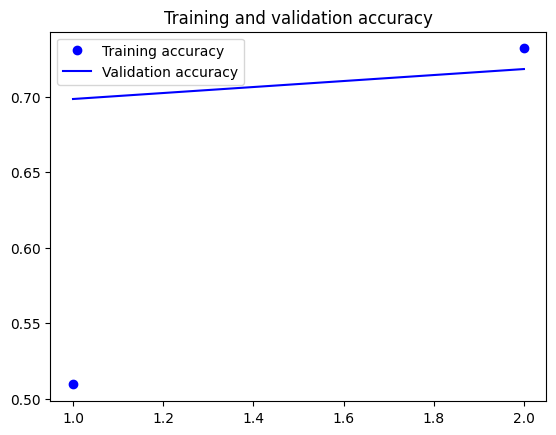

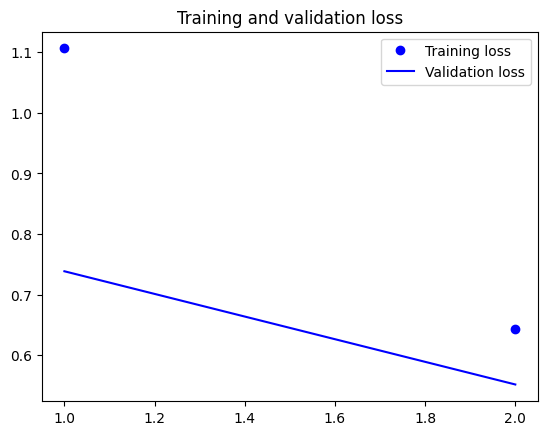

In [33]:
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.savefig(r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 7,8')
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.savefig(r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 7,8\model_Loss.png')

plt.show()

## Section 4: Model Evaluation and Visualization
The final cells evaluate model performance using plots, predictions, confusion matrix, and classification report.


In [35]:
model.save(r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 7,8\\E1-cp-0002-loss0.55.h5')

Found 200 images belonging to 4 classes.


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 428ms/step


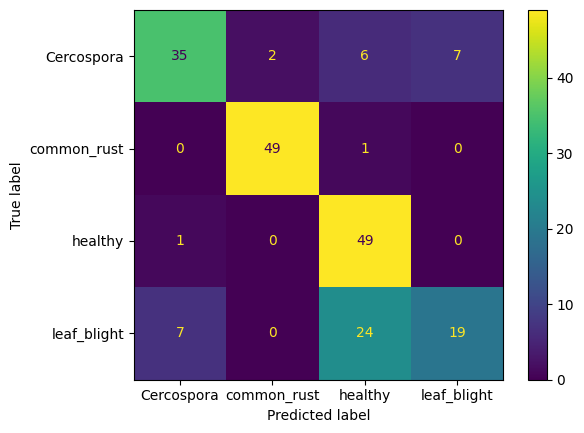

In [36]:
#model = load_model(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_lab11.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'Z:\University\8th Semester\ML Lab\Lab 7,8\confusion_matrics.jpg')

In [37]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.81      0.70      0.75        50
 common_rust       0.96      0.98      0.97        50
     healthy       0.61      0.98      0.75        50
 leaf_blight       0.73      0.38      0.50        50

    accuracy                           0.76       200
   macro avg       0.78      0.76      0.74       200
weighted avg       0.78      0.76      0.74       200



## Conclusion
* In this lab, a custom CNN model was developed and trained for corn leaf disease classification.
* The prepared image dataset was used for model training and validation.
* Training progress was monitored through visual learning curves.
* The model's predictions were analyzed using classification performance metrics.
* Evaluation techniques such as accuracy measurement and graphical analysis were used to assess model performance.
